In [72]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
from functools import partial
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

In [141]:
import treescope
treescope.register_as_default()
treescope.basic_interactive_setup(autovisualize_arrays=True)

In [223]:
# 1) A simple MLP with capture of all layer activations / pre-activations
class MLP(nn.Module):
    hidden_dims: list[int]
    output_dim: int

    @nn.compact
    def __call__(self, x, capture_acts: bool = False):
        # acts[i]  = post-activation of layer i (acts[0] is input)
        # pre_acts[i] = pre-activation of layer i
        acts = [x]
        pre_acts = []
        for i, h in enumerate(self.hidden_dims):
            x = nn.Dense(h, name=f"Dense_{i}", use_bias=False)(x)
            pre_acts.append(x)
            x = nn.relu(x)
            acts.append(x)
        # final output layer
        x = nn.Dense(self.output_dim, name=f"Dense_{len(self.hidden_dims)}", use_bias=False)(x)
        pre_acts.append(x)
        acts.append(x)
        if capture_acts:
            return x, acts, pre_acts
        return x

In [224]:
# mean-squared error
def mse_loss(params, model, x, y):
    preds = model.apply(params, x)
    return jnp.mean((preds - y)**2)

# 3) simple 1D function fitting (sine)
def make_sine_data(n=200):
    xs = jnp.linspace(-jnp.pi, jnp.pi, n).reshape(-1, 1)
    ys = jnp.sin(xs) + jnp.sin(3 * xs) 
    return xs, ys

In [265]:
# # 2) compute K-FAC factors A and G for each Dense layer
# def compute_kfac_factors(params, model, x, y):
#     # forward with capture
#     preds, acts, pre_acts = model.apply(params, x, capture_acts=True)
#     batch_size = x.shape[0]
#     # scalar loss
#     loss = jnp.mean((preds - y)**2)
#     # dL/dpred
#     dL_dp = 2 * (preds - y) / batch_size

#     # backprop deltas for each layer
#     deltas = [None] * len(pre_acts)
#     grad_up = dL_dp
#     # iterate layers backwards
#     for i in reversed(range(len(pre_acts))):
#         z = pre_acts[i]
#         # for all but final layer, apply ReLU grad
#         if i < len(pre_acts) - 1:
#             grad_up = grad_up * (z > 0)
#         deltas[i] = grad_up
#         # propagate to next
#         if i > 0:
#             W = params['params'][f"Dense_{i}"]["kernel"]  # shape (in, out)
#             grad_up = grad_up @ W.T

#     # build list of (A, G)
#     kfac = []
#     for i in range(len(pre_acts)):
#         a = acts[i]      # shape (batch, in_i)
#         d = deltas[i]    # shape (batch, out_i)
#         A = (a.T @ a)   / batch_size
#         G = (d.T @ d)  / batch_size # do we need batch size scaling? 
#         kfac.append({"A": A, "G": G, 'a': a, 'g': d})
#     return kfac

def compute_kfac_factors(params: dict,
                         model,
                         x: jnp.ndarray,
                         y: jnp.ndarray,
                         eps: float = 0.0
                        ):
    """
    Compute K-FAC factors for each Dense layer of `model`.

    - params: Flax params (expected structure params['params']['Dense_i']['kernel'])
    - model: flax.nn.Module instance with .apply(..., capture_acts=True)
    - x: input batch, shape (B, in_dim)
    - y: targets, shape matching preds (B, out_dim)
    - eps: optional damping added to A and G (useful before inverting)
    Returns: list of dicts [{'A':..., 'G':..., 'a': (B, n_in), 'g': (B, n_out)}, ...]
    """

    preds, acts, pre_acts = model.apply(params, x, capture_acts=True)
    B = x.shape[0]

    # --- IMPORTANT: compute per-sample gradient of the per-example squared loss ---
    # per-example loss: ell_b = sum_j (preds[b,j] - y[b,j])**2
    # gradient of ell_b wrt preds[b,*] is 2 * (preds - y)  (no /B)
    residual = preds - y
    dL_dp = 2.0 * residual               # shape (B, out_dim)  <-- per-example gradients

    # Backprop to obtain per-sample pre-activation gradients ("g" in K-FAC)
    deltas = [None] * len(pre_acts)
    grad_up = dL_dp                       # gradient wrt final pre-activation (last layer)
    for i in reversed(range(len(pre_acts))):
        z = pre_acts[i]                   # pre-activation for layer i, shape (B, out_i)

        # For hidden layers, turn gradient wrt activation into gradient wrt pre-activation:
        # grad_up currently either (B, out_i) (for final layer) or (B, out_i) that's gradient wrt activation.
        # ReLU derivative: d a / d s = 1_{s > 0}.
        if i < len(pre_acts) - 1:
            relu_mask = (z > 0).astype(z.dtype)   # cast mask to same float dtype
            grad_up = grad_up * relu_mask

        # store per-sample pre-act gradient for this layer (these are the "g^{(b)}")
        deltas[i] = grad_up

        # propagate gradient wrt pre-activation to gradient wrt previous activation a_{i-1},
        # except when i == 0 (there is no previous dense)
        if i > 0:
            # In Flax Dense, kernel shape is (in_features, out_features)
            W = params['params'][f"Dense_{i}"]["kernel"]   # shape (n_in, n_out)
            # grad_up (B, out) @ W.T (out, in) -> (B, in)
            grad_up = grad_up @ W.T

    # Build A and G (empirical expectations)
    kfac = []
    for i in range(len(pre_acts)):
        a = acts[i]      # shape (B, n_in)  -- activation feeding into layer i
        g = deltas[i]    # shape (B, n_out) -- per-sample pre-act gradients (per-example loss)

        # Empirical covariances (1/B * sum_b ...)
        A = (a.T @ a) / B     # shape (n_in, n_in)
        G = (g.T @ g) / B     # shape (n_out, n_out)

        # optional small damping (helpful before inversion)
        if eps > 0.0:
            A = A + eps * jnp.eye(A.shape[0], dtype=A.dtype)
            G = G + eps * jnp.eye(G.shape[0], dtype=G.dtype)

        kfac.append({"A": A, "G": G, "a": a, "g": g})

    return kfac


def compute_batch_jacobian_gram(params, model, x):
    """
    Compute J J^T (batch Gram) for a scalar-output MLP without bias.
    Args:
      params: model params (PyTree)
      model:  flax.nn.Module (MLP)
      x:      input batch, shape (B, in_dim)

    Returns:
      K: (B, B) ndarray, = J J^T
    """
    # forward with activations + pre-activations
    preds, acts, pre_acts = model.apply(params, x, capture_acts=True)
    batch_size = x.shape[0]

    # Backprop *unit* sensitivities (not loss)
    # start with identity for output (since scalar output, it's just 1)
    deltas = [None] * len(pre_acts)
    grad_up = jnp.ones((batch_size, 1))  # d f / d f = 1

    for i in reversed(range(len(pre_acts))):
        z = pre_acts[i]  # pre-activation
        if i < len(pre_acts) - 1:
            # ReLU derivative
            grad_up = grad_up * (z > 0)
        deltas[i] = grad_up
        if i > 0:
            W = params['params'][f"Dense_{i}"]["kernel"]  # (in_dim, out_dim)
            grad_up = grad_up @ W.T

    # Now accumulate batch Gram: sum over layers
    K = jnp.zeros((batch_size, batch_size))
    for i in range(len(pre_acts)):
        for j in range(len(pre_acts)):
            a = acts[i]     # (B, in_dim)
            aj= acts[j]
            d = deltas[i]   # (B, out_dim)
            dj = deltas[j]
            # each sample’s gradient is vec( a ⊗ d )
            # Gram contribution is (a a^T) ⊙ (d d^T)
            K += (a @ aj.T) * (d @ dj.T)

    return K


In [226]:
# 2b) precondition grads with K-FAC factors
def precondition_grads(params, grads, kfac, damping=1e-2):
    out = {}
    for layer_name, layer_params in grads['params'].items():
        out[layer_name] = {}
        for pname, g in layer_params.items():
            if pname == "kernel":
                # extract layer index
                i = int(layer_name.split("_")[1])
                A = kfac[i]["A"]
                G = kfac[i]["G"]
                # invert with damping
                A_inv = jnp.linalg.inv(A + damping * jnp.eye(A.shape[0]))
                G_inv = jnp.linalg.inv(G + damping * jnp.eye(G.shape[0]))
                # grads g has shape (in, out) in Flax
                # K-FAC uses W as (out, in), so we transpose, precondition, then transpose back
                g_mat = g.T                 # (out, in)
                g_pre = (G_inv @ g_mat @ A_inv).T
                out[layer_name][pname] = g_pre
            else:
                # no preconditioning of biases
                out[layer_name][pname] = g
    return out

def precondition_grads_smw(params, grads, kfac, damping=1e-2):
    for layer_name, layer_params in grads['params'].items():
        for pname, g in layer_params.items():
            if pname == "kernel":
                i = int(layer_name.split("_")[1])
                a = kfac[i]["a"]
                g = kfac[i]["g"]

                a
    # return out

In [227]:
# model & init
model = MLP(hidden_dims=[64, 64, 64], output_dim=1)
key = jax.random.PRNGKey(0)
x_dummy = jnp.zeros((1, 1))
params = model.init(key, x_dummy)

# optimizer hyper-params
lr = 1e-3
damping = 1e-1
epochs = 1

# data
x_train, y_train = make_sine_data(200)


# @partial(jax.jit, static_argnames=['kfac'])
def step(params, x, y, kfac=False):
    # compute loss + grads
    (loss, grads) = jax.value_and_grad(mse_loss)(params, model, x, y)

    if not kfac:
        new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
        return new_params, loss, None
    else:
        # compute K-FAC factors on same batch
        kfac = compute_kfac_factors(params, model, x, y)
        precondition_grads_smw(params, grads, kfac, damping)
        # precondition
        grads_pc = precondition_grads(params, grads, kfac, damping)

        # SGD step
        new_params = jax.tree.map(lambda p, g: p - lr * g, params, {'params': grads_pc})
        
        return new_params, loss, kfac

all_losses_kfac = []
for epoch in tqdm(range(1, epochs + 1)):
    params, loss, kfac = step(params, x_train, y_train, kfac=True)
    all_losses_kfac.append(loss)
    # if epoch % 50 == 0:
    #     print(f"epoch {epoch:3d}, loss = {loss:.6f}")


# all_losses_sgd = []
# for epoch in tqdm(range(1, epochs + 1)):
#     params, loss, kfac = step(params, x_train, y_train, kfac=False)
#     all_losses_sgd.append(loss)
#     # if epoch % 50 == 0:
#     #     print(f"epoch {epoch:3d}, loss = {loss:.6f}")




  0%|          | 0/1 [00:00<?, ?it/s]

In [239]:
kfac = compute_kfac_factors(params, model, x_train, y_train)

In [266]:
compute_batch_jacobian_gram(params, model, x_train) - J @ J.T

TypeError: dot_general requires contracting dimensions to have the same shape, got (1,) and (64,).

In [241]:
params

{'params': {'Dense_0': {'kernel': Array([[-1.6515152 ,  0.7542731 , -1.3770173 , -0.85200995,  0.918971  ,
            1.2828313 ,  1.0442146 , -0.04620984,  0.4228704 ,  0.77602786,
           -1.8192819 ,  0.8536744 , -0.7062777 ,  0.5089937 ,  1.2207831 ,
           -0.27504805, -1.4831561 , -1.3194224 , -0.7113974 , -0.03330998,
           -0.3392417 , -0.62431175, -2.1085162 , -0.5390931 , -1.1494279 ,
           -0.6074997 ,  0.5437576 , -0.7326467 ,  1.2763389 ,  1.2252905 ,
            1.7015096 , -1.464097  ,  0.6201381 ,  1.6955903 ,  0.8770794 ,
           -0.24620555, -0.02442113, -0.84945774,  1.116194  ,  0.47406018,
            0.5860415 , -0.27335724, -0.11777856,  0.6830798 ,  0.48687172,
            0.00450644,  0.39788476, -1.0572873 ,  0.38816303, -1.4145017 ,
           -0.8689923 ,  0.8011333 ,  1.0474892 ,  0.9763218 ,  1.9481943 ,
           -0.0338247 , -0.43503734,  1.0572022 ,  0.4758482 , -0.38553172,
           -1.2396665 ,  0.9401707 , -0.5349997 , -0.65307117]],      dtype=float32)},
  'Dense_1': {'kernel': Array([[ 0.00038905,  0.03991314,  0.02261154, ..., -0.03332036,
            0.14489587,  0.07723609],
          [ 0.05472671, -0.24988905, -0.0062487 , ..., -0.00554853,
           -0.1538829 , -0.03580237],
          [-0.09790631,  0.10281476, -0.06415708, ..., -0.17658144,
            0.02660781, -0.1802741 ],
          ...,
          [ 0.04291615,  0.14339557,  0.11145157, ..., -0.09864441,
            0.07482045,  0.02730833],
          [-0.23197953, -0.01995793,  0.02506591, ..., -0.15356174,
           -0.00762421,  0.0474318 ],
          [-0.2779899 ,  0.07372383, -0.0815929 , ..., -0.19048409,
            0.17905216, -0.22971962]], dtype=float32)},
  'Dense_2': {'kernel': Array([[ 0.1959751 , -0.04540443,  0.05393911, ...,  0.08529598,
            0.15004867, -0.22464031],
          [-0.01274312, -0.05189241,  0.06762924, ...,  0.07055863,
           -0.05602374,  0.24140228],
          [ 0.17025797,  0.17740074, -0.0457088 , ...,  0.07757415,
            0.02734087,  0.15458019],
          ...,
          [-0.15996936,  0.267635  , -0.05369416, ..., -0.1559927 ,
           -0.1505037 ,  0.15392801],
          [-0.04143828, -0.09219193, -0.08138435, ...,  0.05037639,
            0.05995699,  0.16653886],
          [-0.21907322, -0.02157984,  0.18702501, ..., -0.1907923 ,
           -0.12259796,  0.09647141]], dtype=float32)},
  'Dense_3': {'kernel': Array([[ 0.14815167],
          [-0.2178588 ],
          [-0.18597563],
          [-0.11365816],
          [-0.05555383],
          [-0.07811219],
          [-0.19008774],
          [ 0.12813485],
          [ 0.00489197],
          [-0.01300392],
          [-0.08237926],
          [-0.08655649],
          [ 0.02397281],
          [ 0.22123614],
          [ 0.07070983],
          [-0.1566873 ],
          [ 0.13153249],
          [-0.12876427],
          [-0.15693857],
          [-0.04515363],
          [ 0.10245221],
          [-0.14809485],
          [ 0.11959072],
          [ 0.03445302],
          [-0.05811591],
          [ 0.16035283],
          [-0.18399626],
          [-0.04467806],
          [ 0.12134505],
          [ 0.15306205],
          [ 0.0716466 ],
          [ 0.11280565],
          [-0.13910264],
          [-0.11913005],
          [-0.03608087],
          [-0.09985191],
          [ 0.09133071],
          [-0.22321238],
          [-0.17782685],
          [-0.16178511],
          [ 0.12012674],
          [-0.02241744],
          [ 0.00953413],
          [-0.18041037],
          [ 0.08095116],
          [-0.08548863],
          [ 0.20741363],
          [ 0.18062246],
          [-0.13703066],
          [-0.03710845],
          [ 0.22820675],
          [-0.19438471],
          [-0.18651807],
          [-0.00307735],
          [ 0.00164183],
          [-0.09625819],
          [ 0.08733444],
          [ 0.13241516],
          [ 0.1805031 ],
          [ 0.02927461],
          [-0.0952098 ],
          [ 0.13921654],
          [-0.05922

In [242]:
jacobian = jax.jacobian(lambda p: model.apply(p, x_train))(params)

In [260]:
J = jnp.concat([x.reshape((200, -1)) for x in jax.tree.leaves(jacobian)],axis=1)

In [261]:
J @ J.T

Array([[323.88333, 320.6537 , 317.4577 , ...,  74.86861,  75.6487 ,
         76.42131],
       [320.6537 , 317.45642, 314.29218, ...,  74.12319,  74.89551,
         75.66044],
       [317.4577 , 314.29218, 311.15967, ...,  73.39271,  74.15742,
         74.9148 ],
       ...,
       [ 74.86861,  74.12319,  73.39271, ..., 186.12589, 188.05225,
        189.95319],
       [ 75.6487 ,  74.89551,  74.15742, ..., 188.05225, 189.99864,
        191.9192 ],
       [ 76.42131,  75.66044,  74.9148 , ..., 189.95319, 191.9192 ,
        193.85931]], dtype=float32)

In [244]:
block1 @ block1.T

Array([[106.20333 , 105.147316, 104.111496, ...,  47.483864,  47.9771  ,
         48.469128],
       [105.147316, 104.10183 , 103.07629 , ...,  47.01063 ,  47.49895 ,
         47.98608 ],
       [104.111496, 103.07629 , 102.06089 , ...,  46.551704,  47.03526 ,
         47.517628],
       ...,
       [ 47.483864,  47.01063 ,  46.551704, ...,  56.121155,  56.701324,
         57.279453],
       [ 47.9771  ,  47.49895 ,  47.03526 , ...,  56.701324,  57.287506,
         57.8716  ],
       [ 48.469128,  47.98608 ,  47.517628, ...,  57.279453,  57.8716  ,
         58.461685]], dtype=float32)

In [247]:
 (kfac[-1]['a'] @ kfac[-1]['a'].T)

Array([[106.20333 , 105.147316, 104.111496, ...,  47.483864,  47.9771  ,
         48.469128],
       [105.147316, 104.10183 , 103.07629 , ...,  47.01063 ,  47.49895 ,
         47.98608 ],
       [104.111496, 103.07629 , 102.06089 , ...,  46.551704,  47.03526 ,
         47.517628],
       ...,
       [ 47.483864,  47.01063 ,  46.551704, ...,  56.121155,  56.701324,
         57.279453],
       [ 47.9771  ,  47.49895 ,  47.03526 , ...,  56.701324,  57.287506,
         57.8716  ],
       [ 48.469128,  47.98608 ,  47.517628, ...,  57.279453,  57.8716  ,
         58.461685]], dtype=float32)

In [248]:
(kfac[-1]['g']) @ (kfac[-1]['g']).T

Array([[29.680542, 28.013222, 26.351059, ..., 28.973673, 27.884224,
        26.782967],
       [28.013222, 26.439564, 24.870773, ..., 27.34606 , 26.317812,
        25.27842 ],
       [26.351059, 24.870773, 23.39507 , ..., 25.723484, 24.756248,
        23.778526],
       ...,
       [28.973673, 27.34606 , 25.723484, ..., 28.283638, 27.220137,
        26.145105],
       [27.884224, 26.317812, 24.756248, ..., 27.220137, 26.196623,
        25.162016],
       [26.782967, 25.27842 , 23.778526, ..., 26.145105, 25.162016,
        24.16827 ]], dtype=float32)

In [181]:
sum(x.size for x in jax.tree.leaves(params)) - (2 * (64 * 64))

128

In [157]:
kfac[0]['g'].T @ kfac[0]['g']

Array([[ 1.1778385e-04,  0.0000000e+00,  9.9167366e-05, ...,
         0.0000000e+00, -4.3317763e-05, -3.2750588e-05],
       [ 0.0000000e+00,  7.6876910e-05,  0.0000000e+00, ...,
         1.1064390e-04,  0.0000000e+00,  0.0000000e+00],
       [ 9.9167366e-05,  0.0000000e+00,  8.5439649e-05, ...,
         0.0000000e+00, -3.8496684e-05, -3.0270312e-05],
       ...,
       [ 0.0000000e+00,  1.1064390e-04,  0.0000000e+00, ...,
         1.6364928e-04,  0.0000000e+00,  0.0000000e+00],
       [-4.3317763e-05,  0.0000000e+00, -3.8496684e-05, ...,
         0.0000000e+00,  2.2317859e-05,  1.8319912e-05],
       [-3.2750588e-05,  0.0000000e+00, -3.0270312e-05, ...,
         0.0000000e+00,  1.8319912e-05,  1.7761924e-05]], dtype=float32)

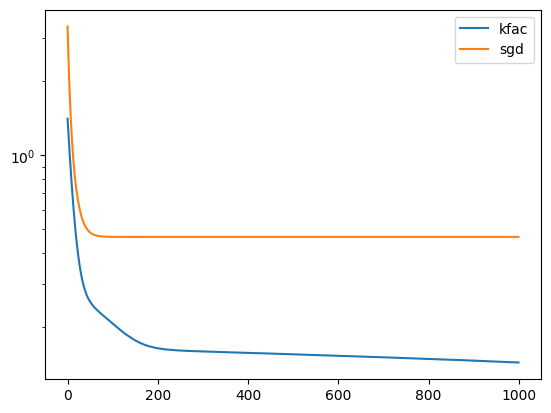

In [158]:
plt.semilogy(all_losses_kfac, label='kfac')
plt.semilogy(all_losses_sgd, label='sgd')
plt.legend()